# Summary: quality + post-hoc cost

Đọc `results/**/scores.jsonl` + `configs/pricing.yaml`. **Không gọi LLM.** Không sửa raw `calls/` / `scores.jsonl`.


In [1]:
%pip install -q pyyaml pandas matplotlib



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
from pathlib import Path

HERE = Path.cwd().resolve()
REPO = None
for c in [HERE, *HERE.parents]:
    if (c / "configs" / "pricing.yaml").exists():
        REPO = c
        break
    if (c / "doan" / "configs" / "pricing.yaml").exists():
        REPO = c / "doan"
        break
if REPO is None:
    REPO = Path("/Users/nguyenkz/Documents/code/CS2202.CH202/doan")
sys.path.insert(0, str(REPO / "src"))
print("REPO:", REPO)


REPO: /Users/nguyenkz/Documents/code/CS2202.CH202/doan


In [3]:
from plausibility_eval.summary import summarize_all
from plausibility_eval.io_utils import load_yaml

exp = load_yaml(REPO / "configs" / "experiment.yaml")
out = summarize_all(repo=REPO, coarse_threshold=float(exp.get("coarse_threshold") or 3.0))
print("n_runs:", out["n_runs"])
print("SUMMARY:", out["summary_md"])
print("CSV:", out["summary_csv"])


n_runs: 21
SUMMARY: /Users/nguyenkz/Documents/code/CS2202.CH202/doan/results/SUMMARY.md
CSV: /Users/nguyenkz/Documents/code/CS2202.CH202/doan/results/SUMMARY.csv


In [4]:
import pandas as pd
from IPython.display import display, Markdown

df = pd.read_csv(out["summary_csv"])
display(df)
display(Markdown(Path(out["summary_md"]).read_text(encoding="utf-8")))


,model_id,mode,n_scored,pearson_r,mae,rmse,parse_fail_rate,total_tokens,mean_cost_per_sentence_usd,cost_ratio_vs_human,coarse_acc,pricing_as_of
0,deepseek/deepseek-v4-flash,ORIG,50,0.548818,0.699936,0.954399,0.000000,692160,0.001282,0.000399,1.00,2026-07-25
1,deepseek/deepseek-v4-flash,S,50,0.413409,0.796864,1.032568,0.000000,951048,0.001749,0.000544,0.98,2026-07-25
2,deepseek/deepseek-v4-flash,ST,50,0.492897,0.944017,1.220459,0.001000,1251732,0.002832,0.000881,0.98,2026-07-25
3,deepseek/deepseek-v4-flash,T,50,0.594378,0.769484,1.045238,0.000000,2369004,0.006109,0.001899,0.96,2026-07-25
4,gemini-3.6-flash,ORIG,1,NaN,0.268300,0.268300,0.000000,3664,0.000614,0.000187,1.00,2026-07-25
5,google/gemini-3.6-flash,T,50,0.680970,0.816644,1.059275,0.000000,781311,0.032796,0.010198,0.98,2026-07-25
6,google/gemma-3-12b-it,ORIG,50,0.640247,1.186496,1.456320,0.000000,732140,0.015443,0.004802,0.88,2026-07-25
7,google/gemma-3-12b-it,S,50,0.584313,1.120716,1.348386,0.000000,774628,0.017992,0.005595,0.86,2026-07-25
8,google/gemma-4-31b-it,ORIG,50,0.488009,0.930984,1.216174,0.000000,741140,0.015623,0.004858,0.98,2026-07-25
9,google/gemma-4-31b-it,S,50,0.619249,0.906644,1.158432,0.000000,785547,0.017759,0.005522,0.96,2026-07-25


# Experiment summary (quality + post-hoc cost)

Pricing as_of: `2026-07-25`

| Model | Mode | n | Pearson r | MAE | RMSE | Parse fail rate | Tokens | $/sentence | vs human | Coarse acc |
|---|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| deepseek/deepseek-v4-flash | ORIG | 50 | 0.5488 | 0.6999 | 0.9544 | 0.0000 | 692160 | 0.001282 | 0.0004 | 1.0000 |
| deepseek/deepseek-v4-flash | S | 50 | 0.4134 | 0.7969 | 1.0326 | 0.0000 | 951048 | 0.001749 | 0.0005 | 0.9800 |
| deepseek/deepseek-v4-flash | ST | 50 | 0.4929 | 0.9440 | 1.2205 | 0.0010 | 1251732 | 0.002832 | 0.0009 | 0.9800 |
| deepseek/deepseek-v4-flash | T | 50 | 0.5944 | 0.7695 | 1.0452 | 0.0000 | 2369004 | 0.006109 | 0.0019 | 0.9600 |
| gemini-3.6-flash | ORIG | 1 |  | 0.2683 | 0.2683 | 0.0000 | 3664 | 0.000614 | 0.0002 | 1.0000 |
| google/gemini-3.6-flash | T | 50 | 0.6810 | 0.8166 | 1.0593 | 0.0000 | 781311 | 0.032796 | 0.0102 | 0.9800 |
| google/gemma-3-12b-it | ORIG | 50 | 0.6402 | 1.1865 | 1.4563 | 0.0000 | 732140 | 0.015443 | 0.0048 | 0.8800 |
| google/gemma-3-12b-it | S | 50 | 0.5843 | 1.1207 | 1.3484 | 0.0000 | 774628 | 0.017992 | 0.0056 | 0.8600 |
| google/gemma-4-31b-it | ORIG | 50 | 0.4880 | 0.9310 | 1.2162 | 0.0000 | 741140 | 0.015623 | 0.0049 | 0.9800 |
| google/gemma-4-31b-it | S | 50 | 0.6192 | 0.9066 | 1.1584 | 0.0000 | 785547 | 0.017759 | 0.0055 | 0.9600 |
| google/gemma-4-31b-it | ST | 50 | 0.5545 | 0.9499 | 1.2004 | 0.0000 | 1593100 | 0.066820 | 0.0208 | 0.9600 |
| google/gemma-4-31b-it | T | 50 | 0.6421 | 0.8146 | 1.0718 | 0.0010 | 1593779 | 0.066501 | 0.0207 | 0.9600 |
| gpt-5.6-luna | ORIG | 50 | 0.7777 | 0.6199 | 0.7857 | 0.0000 | 697160 | 0.014743 | 0.0046 | 0.9800 |
| gpt-5.6-luna | T | 50 | 0.7851 | 0.5740 | 0.7494 | 0.0000 | 788178 | 0.020204 | 0.0063 | 0.9800 |
| gpt-5.6-sol | ORIG | 50 | 0.7331 | 0.6378 | 0.8549 | 0.0000 | 348578 | 0.019928 | 0.0062 | 0.9800 |
| gpt-5.6-sol | T | 50 | 0.7062 | 0.6758 | 0.9037 | 0.0000 | 379474 | 0.029197 | 0.0091 | 0.9800 |
| moonshotai/kimi-k3 | ORIG | 50 | 0.6918 | 0.6680 | 0.9270 | 0.0000 | 182535 | 0.003851 | 0.0012 | 0.9400 |
| moonshotai/kimi-k3 | T | 50 | 0.6954 | 0.6498 | 0.8329 | 0.0000 | 456934 | 0.013410 | 0.0042 | 0.9600 |
| openai/gpt-4.1-mini | ORIG | 50 | 0.5251 | 0.8717 | 1.1519 | 0.0000 | 719139 | 0.016022 | 0.0050 | 0.9200 |
| z-ai/glm-5.2 | ORIG | 50 | 0.6282 | 0.8656 | 1.0943 | 0.0000 | 172545 | 0.003651 | 0.0011 | 0.9600 |
| z-ai/glm-5.2 | T | 50 | 0.6678 | 0.9251 | 1.1780 | 0.0307 | 1385865 | 0.062866 | 0.0195 | 0.8600 |

Notes:
- USD computed **after** eval from token logs × `configs/pricing.yaml`.
- Raw `calls/` and `scores.jsonl` are not modified.
- Self-host rows may have `cost_mode: estimated_gpu` (often $0 placeholder).


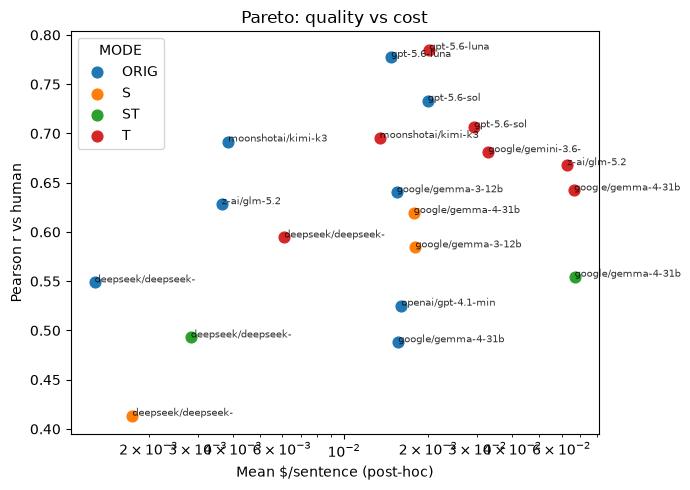

saved results/pareto_quality_cost.png


In [5]:
# Pareto: cost vs Pearson r (skip empty)
import matplotlib.pyplot as plt

plot_df = df.dropna(subset=["pearson_r", "mean_cost_per_sentence_usd"]).copy()
if len(plot_df) == 0:
    print("No runs with both r and cost yet — run eval first.")
else:
    fig, ax = plt.subplots(figsize=(7, 5))
    for mode, g in plot_df.groupby("mode"):
        ax.scatter(g["mean_cost_per_sentence_usd"], g["pearson_r"], label=mode, s=60)
        for _, row in g.iterrows():
            ax.annotate(str(row["model_id"])[:18], (row["mean_cost_per_sentence_usd"], row["pearson_r"]), fontsize=7, alpha=0.8)
    ax.set_xlabel("Mean $/sentence (post-hoc)")
    ax.set_ylabel("Pearson r vs human")
    ax.set_title("Pareto: quality vs cost")
    ax.legend(title="MODE")
    ax.set_xscale("log")
    fig.tight_layout()
    fig.savefig(REPO / "results" / "pareto_quality_cost.png", dpi=150)
    plt.show()
    print("saved results/pareto_quality_cost.png")


**Mục tiêu:** đo mức gần **Human** (Pearson *r*, MAE, RMSE, coarse).

**Tham chiếu paper** (cùng 50 câu): GPT-4 ORIG — *r*=0.7547, MAE=0.5822, coarse@3=96.00%  
`gpt_4__prompt_1##mem_enc##num_ex#3##diff_sentence#no__temp_1.5`

,source,model_id,mode,n_scored,pearson_r,mae,rmse,coarse_acc,delta_r_vs_paper,delta_mae_vs_paper
0,ours,gpt-5.6-luna,T,50,0.7851,0.5740,0.7494,0.98,0.0304,-0.0082
1,ours,gpt-5.6-luna,ORIG,50,0.7777,0.6199,0.7857,0.98,0.0230,0.0377
2,paper-ref,gpt-4 (paper),ORIG,50,0.7547,0.5822,0.7488,0.96,0.0000,0.0000
3,ours,gpt-5.6-sol,ORIG,50,0.7331,0.6378,0.8549,0.98,-0.0216,0.0555
4,ours,gpt-5.6-sol,T,50,0.7062,0.6758,0.9037,0.98,-0.0485,0.0935
5,ours,moonshotai/kimi-k3,T,50,0.6954,0.6498,0.8329,0.96,-0.0593,0.0675
6,ours,moonshotai/kimi-k3,ORIG,50,0.6918,0.6680,0.9270,0.94,-0.0629,0.0857
7,ours,google/gemini-3.6-flash,T,50,0.6810,0.8166,1.0593,0.98,-0.0737,0.2344
8,ours,z-ai/glm-5.2,T,50,0.6678,0.9251,1.1780,0.86,-0.0869,0.3428
9,ours,google/gemma-4-31b-it,T,50,0.6421,0.8146,1.0718,0.96,-0.1126,0.2324


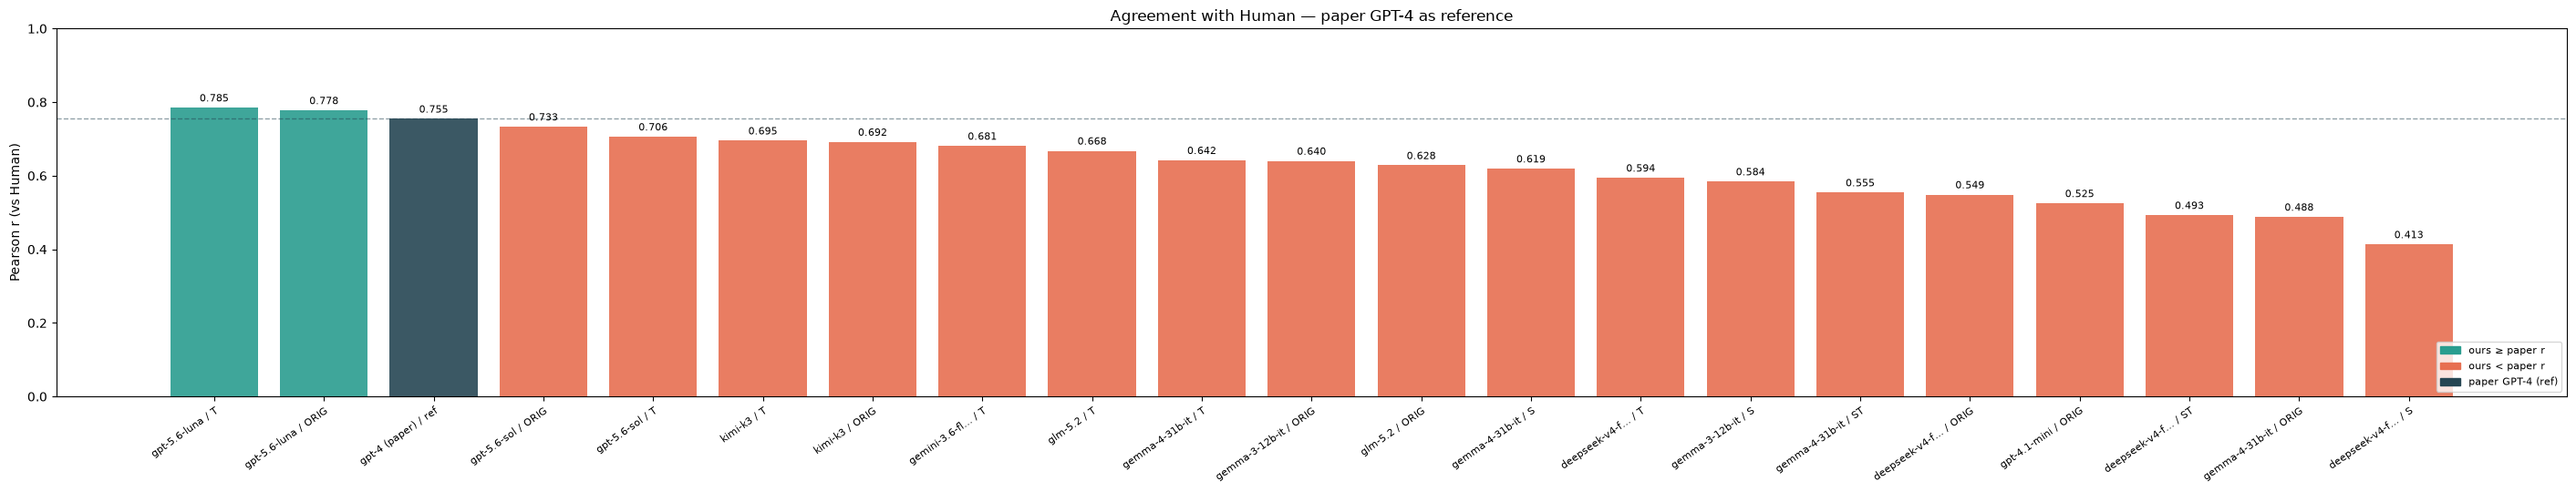

saved results/compare_vs_human_paper_ref.png
Best vs Human: gpt-5.6-luna [<bound method Series.mode of model_id              gpt-5.6-luna
mode                             T
n_scored                        50
pearson_r                 0.785097
mae                       0.573984
rmse                       0.74938
coarse_acc                    0.98
source                        ours
delta_r_vs_paper          0.030397
delta_mae_vs_paper       -0.008248
Name: 0, dtype: object>]  r=0.7851  MAE=0.5740  (Δr vs paper ref +0.0304)


In [6]:
# So sánh với Human (+ paper GPT-4 làm cột tham chiếu trên cùng thang)
# Metric chính = gần human hơn (Pearson r ↑, MAE ↓).
# Paper GPT-4 = reference trên cùng 50 câu mem_enc (ORIG, num_ex=3, diff=no, temp=1.5).
# Không gọi LLM.

import json
import math
from IPython.display import display, Markdown
from plausibility_eval.metrics import _pearson, coarse_accuracy

PAPER_DATA = REPO / "data" / "ready" / "mem_enc_human_and_gpt.jsonl"
paper_rows = [json.loads(l) for l in PAPER_DATA.read_text(encoding="utf-8").splitlines() if l.strip()]
if not paper_rows:
    raise FileNotFoundError(f"Empty paper data: {PAPER_DATA}")

T = float(exp.get("coarse_threshold") or 3.0)

def _paper_metrics(score_key: str) -> dict:
    rows = [{"human_mean": r["human_mean"], "model_mean": r[score_key]} for r in paper_rows]
    h = [float(r["human_mean"]) for r in rows]
    m = [float(r["model_mean"]) for r in rows]
    n = len(h)
    return {
        "n_scored": n,
        "pearson_r": _pearson(h, m),
        "mae": sum(abs(a - b) for a, b in zip(h, m)) / n,
        "rmse": math.sqrt(sum((a - b) ** 2 for a, b in zip(h, m)) / n),
        "coarse_acc": coarse_accuracy(rows, T),
        "run_tag": paper_rows[0].get(score_key.replace("_mean", "_run"), score_key),
    }

paper_gpt4 = _paper_metrics("gpt4_mean")
paper_ref_r = float(paper_gpt4["pearson_r"])
paper_ref_mae = float(paper_gpt4["mae"])

display(Markdown(
    "**Mục tiêu:** đo mức gần **Human** (Pearson *r*, MAE, RMSE, coarse).\n\n"
    f"**Tham chiếu paper** (cùng 50 câu): GPT-4 ORIG — "
    f"*r*={paper_ref_r:.4f}, MAE={paper_ref_mae:.4f}, "
    f"coarse@{T:g}={paper_gpt4['coarse_acc']:.2%}  \n"
    f"`{paper_gpt4['run_tag']}`"
))

ours = df.dropna(subset=["pearson_r"]).copy()
if len(ours) == 0:
    print("No runs with pearson_r yet.")
else:
    # Table: our runs + paper GPT-4 as one reference row (same human-relative metrics)
    table = ours[["model_id", "mode", "n_scored", "pearson_r", "mae", "rmse", "coarse_acc"]].copy()
    table["source"] = "ours"
    table["delta_r_vs_paper"] = table["pearson_r"] - paper_ref_r  # >0 = gần human hơn paper
    table["delta_mae_vs_paper"] = table["mae"] - paper_ref_mae    # <0 = gần human hơn paper

    ref = pd.DataFrame([{
        "model_id": "gpt-4 (paper)",
        "mode": "ORIG",
        "n_scored": paper_gpt4["n_scored"],
        "pearson_r": paper_ref_r,
        "mae": paper_ref_mae,
        "rmse": paper_gpt4["rmse"],
        "coarse_acc": paper_gpt4["coarse_acc"],
        "source": "paper-ref",
        "delta_r_vs_paper": 0.0,
        "delta_mae_vs_paper": 0.0,
    }])
    combined = pd.concat([table, ref], ignore_index=True)
    combined = combined.sort_values("pearson_r", ascending=False).reset_index(drop=True)

    show_cols = [
        "source", "model_id", "mode", "n_scored",
        "pearson_r", "mae", "rmse", "coarse_acc",
        "delta_r_vs_paper", "delta_mae_vs_paper",
    ]
    show_disp = combined[show_cols].copy()
    for c in ("pearson_r", "mae", "rmse", "coarse_acc", "delta_r_vs_paper", "delta_mae_vs_paper"):
        show_disp[c] = show_disp[c].map(lambda x: None if pd.isna(x) else round(float(x), 4))
    display(show_disp)

    # Bar chart: Pearson r vs Human — our runs + paper reference as a column
    n_bars = len(combined)
    fig, ax = plt.subplots(figsize=(max(10, 1.35 * n_bars), 5.5))
    labels = []
    colors = []
    for row in combined.itertuples():
        short = str(row.model_id).split("/")[-1]
        # compact common names so ticks stay readable
        if len(short) > 14:
            short = short[:13] + "…"
        if row.source == "paper-ref":
            labels.append(f"{short} / ref")
            colors.append("#264653")
        else:
            labels.append(f"{short} / {row.mode}")
            colors.append("#2a9d8f" if row.delta_r_vs_paper >= 0 else "#e76f51")

    bars = ax.bar(range(n_bars), combined["pearson_r"], color=colors, alpha=0.9)
    for bar, val in zip(bars, combined["pearson_r"]):
        ax.annotate(
            f"{val:.3f}",
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8,
        )
    ax.axhline(paper_ref_r, color="#264653", ls="--", lw=1, alpha=0.5)
    ax.set_xticks(range(n_bars))
    ax.set_xticklabels(labels, fontsize=8, rotation=35, ha="right", rotation_mode="anchor")
    ax.set_ylabel("Pearson r (vs Human)")
    ax.set_title("Agreement with Human — paper GPT-4 as reference")
    ax.set_ylim(0, 1)
    ax.legend(
        handles=[
            plt.Rectangle((0, 0), 1, 1, color="#2a9d8f", label="ours ≥ paper r"),
            plt.Rectangle((0, 0), 1, 1, color="#e76f51", label="ours < paper r"),
            plt.Rectangle((0, 0), 1, 1, color="#264653", label="paper GPT-4 (ref)"),
        ],
        loc="lower right",
        fontsize=8,
    )
    fig.tight_layout()
    out_png = REPO / "results" / "compare_vs_human_paper_ref.png"
    fig.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.show()
    print("saved", out_png.relative_to(REPO))

    best = combined[combined["source"] == "ours"].iloc[0]
    print(
        f"Best vs Human: {best.model_id} [{best.mode}]  "
        f"r={best.pearson_r:.4f}  MAE={best.mae:.4f}  "
        f"(Δr vs paper ref {best.delta_r_vs_paper:+.4f})"
    )
